# Tarefa 3 - Neural Networks Coursework 2026

Third assessed coursework for **Tecnicas e Algoritmos em Ciencia de Dados**.

Write your 6-digit anonymous identifier in the first code cell. Submit a single notebook named with that identifier, for example `568423.ipynb`. Do not submit datasets or extra Python scripts. Any helper function used by your solution must be included in this notebook.

This notebook is a guide. The TODO cells mark the parts you must implement. The TensorFlow baseline cells are provided so you can compare your own implementations against a standard neural-network baseline.

## Overview

1. Regression with neural networks (50%)
2. Multiclass classification with neural networks (50%)

## General rules

- You may use NumPy and basic libraries for matrix operations.
- You must not use library implementations for the algorithms you are asked to implement manually.
- Standardize features manually using only training-set statistics.
- Use the validation set for model selection.
- Use the test set only for final reporting.
- Restart the kernel and run the full notebook before submitting.


In [2]:
student_id = "708024"  # Replace with your 6-digit anonymous identifier.
student_id


'708024'

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import sklearn

np.random.seed(0)


In [6]:
# My Versions
print(f"SNS: {sns.__version__}")
print(f"PD: {pd.__version__}")
print(f"NP: {np.__version__}")

SNS: 0.13.2
PD: 3.0.1
NP: 2.4.3


In [5]:
# Versions
print(f"SNS: {sns.__version__}")
print(f"PD: {pd.__version__}")
print(f"NP: {np.__version__}")

SNS: 0.13.2
PD: 3.0.1
NP: 2.4.3


# Helper Functions

Implement any shared helper functions here. In particular, you will need a function to standardize validation and test data using the mean and standard deviation computed from the training set.

Do not use `sklearn.preprocessing.StandardScaler` for this coursework requirement.


In [7]:
import sklearn.metrics


def standardize_from_train(X_train, X_val, X_test, return_mean_std = False):
    """Standardize X_train, X_val, and X_test using training-set statistics only."""
    feature_means = np.mean(X_train, axis= 0)
    feature_std = np.std(X_train, axis= 0)
    feature_std[feature_std == 0] = 1

    X_train = (X_train - feature_means) / feature_std
    X_val = (X_val - feature_means) / feature_std
    X_test = (X_test - feature_means) / feature_std
    
    if return_mean_std:
        return X_train, X_val, X_test, feature_means, feature_std
    
    return X_train, X_val, X_test


def rmse(y_true, y_pred):
    """Return the root mean squared error."""
    return np.sqrt(np.mean((y_true - y_pred)**2))


def multiclass_metrics(y_true_one_hot, predicted_probabilities, predicted_labels):
    """Compute AUROC, precision, F1, and accuracy for multiclass predictions."""

    auroc = sklearn.metrics.auc(y_true_one_hot, predicted_probabilities)
    precision = sklearn.metrics.precision_score(y_true_one_hot, predicted_labels)
    f1_score = sklearn.metrics.f1_score(y_true_one_hot, predicted_labels)
    accuracy = sklearn.metrics.accuracy_score(y_true_one_hot, predicted_labels)

    print(f"AUROC: {auroc} | Precision: {precision} | F1-score: {f1_score} | Accuracy: {accuracy}")


# Part 1 - Regression With Neural Networks (50%)

## Dataset

Use `student_performance.csv`. Each row corresponds to a student. The target is `final_score`.

Required preprocessing:

1. Load the dataset.
2. Data cleaning, droping duplicates, and convert categorical variables to numerical variables.
3. Use `final_score` as the regression target.
4. Do not use `student_id` as a feature.
5. Do not use `passed` as a feature because it is derived from the final score.
6. Split the data into training, validation, and test sets using a 70:15:15 ratio.
7. Standardize features manually using only training-set statistics.


In [8]:
raw = pd.read_csv("student_performance.csv")
display(raw.head())
display(raw.describe(include="all"))


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
count,500,500,500.000000,500.000000,500.000000,383,500,500,500.000000,500.000000,500
unique,500,2,NaN,NaN,NaN,4,2,2,NaN,NaN,2
top,STU0001,Female,NaN,NaN,NaN,Master,Yes,No,NaN,NaN,Yes
freq,1,273,NaN,NaN,NaN,100,254,253,NaN,NaN,323
mean,NaN,NaN,16.978000,15.312000,76.380600,NaN,NaN,NaN,62.986000,55.980000,NaN
std,NaN,NaN,1.434445,8.568167,13.817681,NaN,NaN,NaN,18.937451,15.373754,NaN
min,NaN,NaN,15.000000,2.000000,50.200000,NaN,NaN,NaN,30.000000,20.000000,NaN
25%,NaN,NaN,16.000000,8.000000,64.475000,NaN,NaN,NaN,46.000000,45.000000,NaN
50%,NaN,NaN,17.000000,15.000000,76.500000,NaN,NaN,NaN,64.000000,56.000000,NaN
75%,NaN,NaN,18.000000,23.000000,88.525000,NaN,NaN,NaN,79.000000,68.000000,NaN


In [9]:
performance = raw.dropna()
performance = performance.drop_duplicates()

performance.drop(columns= ["student_id", "passed"], inplace= True) #Como nós não vamos utilizar essas colunas, já retirei elas

In [10]:
performance.dtypes

gender                      str
age                       int64
study_hours_per_week      int64
attendance_rate         float64
parent_education            str
internet_access             str
extracurricular             str
previous_score            int64
final_score               int64
dtype: object

In [11]:
#Encontrando quais são as varáveis categóricas
for column in performance.columns:
    if performance[column].dtype == "str":
        print(performance[column].unique())

<StringArray>
['Male', 'Female']
Length: 2, dtype: str
<StringArray>
['Bachelor', 'High School', 'Master', 'PhD']
Length: 4, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [12]:
#Convertendo as variáveis categóricas para variáveis discretas
gender_map = {"Male"  : 1,
              "Female": 2}

parent_education_map = {"Bachelor"    : 1,
                        "High School" : 2,
                        "Master"      : 3,
                        "PhD"         : 4}

internet_acess_map = {"Yes": 1,
                      "No" : 2}

extracurricular_map  = {"Yes": 1,
                    "No" : 2}

performance["gender"] = performance["gender"].map(gender_map)
performance["parent_education"] = performance["parent_education"].map(parent_education_map)
performance["internet_access"] = performance["internet_access"].map(internet_acess_map)
performance["extracurricular"] = performance["extracurricular"].map(extracurricular_map)


In [13]:
performance.dtypes

gender                    int64
age                       int64
study_hours_per_week      int64
attendance_rate         float64
parent_education          int64
internet_access           int64
extracurricular           int64
previous_score            int64
final_score               int64
dtype: object

In [14]:
X = performance.values[:,:-1]
y = performance.values[:,-1]

In [15]:
X_train, X_aux, y_train, y_aux = train_test_split(X, y, train_size = 0.7)
X_val, X_test, y_val, y_test = train_test_split(X_aux, y_aux, train_size = 0.5)

In [16]:
X_train, X_val, X_test = standardize_from_train(X_train, X_val, X_test)

## NumPy Regression Neural Network

Implement a fully connected neural network using NumPy.

Requirements:

- The number of hidden layers must be configurable. $\textit{FEITO (parâmetro hidden\_layers possibilita isso)}$
- Every hidden layer must have the same number of neurons. $\textit{FEITO (Ao inicializar os parâmetros inicializamos todas as matrizes das hidden layers com mesma dimensão)}$
- Use sigmoid activation functions in hidden layers. $\textit{FEITO (parâmetro hidden\_activation possibilita isso)}$
- Use a linear output layer. $\textit{FEITO (parâmetro output\_activation possibilita isso) }$
- Implement forward propagation manually. $\textit{FEITO}$
- Implement backpropagation manually. $\textit{FEITO}$
- Support three update methods: batch gradient descent, stochastic gradient descent, and mini-batch gradient descent. $\textit{FEITO (É possível escolher o método através de um parâmetro na função fit)}$
- Use early stopping to prevent overfitting. $\textit{FEITO}$
- Track training and validation loss at each epoch. $\textit{FEITO (A função fit retorna uma lista com os valores de cada epoch)}$
- Use learning rate `0.01`. $\textit{FEITO}$
- Train for at most `50` epochs. $\textit{FEITO}$


In [ ]:
# If you want to implement without using POO, you can implement the following functions instead of the NeuralNetworkRegression class.
# My recommended approach is to implement the class, but you can implement the following functions if you prefer a functional programming style.
class NeuralNetworkRegression:
    def __init__(self, input_size, hidden_layers, neurons_per_layer, output_size=1):
        # TODO: initialize weights and biases for a variable number of layers.
        raise NotImplementedError

    def forward(self, X):
        # TODO: implement the forward pass.
        raise NotImplementedError

    def backward(self, activations, y_true):
        # TODO: implement backpropagation.
        raise NotImplementedError

    def fit(
        self,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=50,
        learning_rate=0.01,
        update_method="mini_batch",
        batch_size=32,
        patience=10,
    ):
        # TODO: implement training with batch, SGD, and mini-batch updates.
        # TODO: implement early stopping and restore the best weights.
        # TODO: return training and validation loss histories.
        raise NotImplementedError

    def predict(self, X):
        # TODO: return predictions from the network.
        raise NotImplementedError


In [17]:
class ActivationFunction:
    
    def __init__(self, function, derivative = None):
        self.function = function
        self.derivative = derivative
        
def sigmoid(a): return 1/(1 + np.exp(-a))
def sigmoid_prime(a): return sigmoid(a) * (1 - sigmoid(a))

sigmoid_activation = ActivationFunction(sigmoid, sigmoid_prime)

def softmax(a):
    exp_a = np.exp(a)
    return exp_a / exp_a.sum(axis=1, keepdims=True)

def identity(a): return a

In [ ]:
class MultilayerPerceptron:

    def __init__(self, hidden_activation: ActivationFunction, output_activation, input_size: int, hidden_layers: int, neurons_per_layer: int, output_size: int = 1):
        """A lista "sizes" deve conter todas as dimensões das camadas da nossa rede, desde a dimensão de entrada
        até a de saída. Tanto os pesos, quanto os biases estarão na matriz de parâmetros."""

        self.num_layers = hidden_layers + 1
        self.num_hidden_layers = hidden_layers
        self.sizes = (input_size, neurons_per_layer, output_size)
        self.hidden_activation = hidden_activation.function
        self.hidden_activation_prime = hidden_activation.derivative
        self.output_activation = output_activation
        self._initialize_parameters()
    

    def _initialize_parameters(self):
        "Inicializa os parâmetros da rede com todas as camadas ocultas com mesmo número de neurônios."
        input_size, hidden_size, output_size = self.sizes
        sizes = [input_size]
        
        for i in range(self.num_hidden_layers):
            sizes.append(hidden_size)
        sizes.append(output_size)
        
        self.parameters = [np.random.randn(y, x + 1) * 0.01 for x,y in zip(sizes[:-1], sizes[1:])]
    

    @staticmethod
    def _add_ones(X):
        """Essa função vai nos permitir adicionar uma coluna de 1s aos nossos dados, para conseguirmos 
        multiplicar pelos biases."""
        return np.column_stack((np.ones(X.shape[0]), X))
    

    def _forward_pass(self, X):
        z = self._add_ones(X)
        Zs = [z]
        As = []
        
        #Hidden Layers
        for w in self.parameters[:-1]:
            a = z @ w.T
            As.append(a)
            
            z = self.hidden_activation(a) 
            z = self._add_ones(z)
            Zs.append(z)

        #Output Layer
        W_output = self.parameters[-1]
        a = z @ W_output.T
        y = self.output_activation(a)

        return y, Zs, As
    

    def _fast_forward_pass(self, X):
        """Realiza o forward_pass sem ficar armazendo os valores necessários para o backpropagation."""
        z = self._add_ones(X)
        
        #Hidden Layers
        for w in self.parameters[:-1]:
            a = z @ w.T
            
            z = self.hidden_activation(a) 
            z = self._add_ones(z)

        #Output Layer
        W_output = self.parameters[-1]
        a = z @ W_output.T
        y = self.output_activation(a)

        return y

    @staticmethod
    def _output_derivative(y_prev, target):
        """Calcula o delta de saída."""
        return y_prev - target
    
    def backpropagation():
        return NotImplementedError
    
    def compute_loss():
        return NotImplementedError
    
    def fit(self, 
            X_train, 
            y_train, 
            X_val,
            y_val,
            update_method = "mini_batch",
            batch_size = 32, 
            lr = 0.01, 
            epochs=1, 
            weight_decay = 0.0,
            patience = 10):
        
        """Treina os parâmetros da nossa rede utilizando o método de mini_batch. Os casos do Stochastic Gradient Descent (SGD)
        e do método batch, são os casos especiais em que batch_size = 1 e batch_size = X.shape[0] (número de data points), respectivamente."""

        if update_method == "sgd": batch_size = 1
        if update_method == "batch": batch_size = X_train.shape[0]
            
        n_samples = X_train.shape[0]
        loss_history_train, loss_history_val = [], [] 
        
        best_val_loss = float('inf')
        best_parameters = [w.copy() for w in self.parameters]
        no_improve = 0

        for epoch in range(epochs):
            idx = np.random.permutation(n_samples)
            X_shuffled, y_shuffled = X_train[idx], y_train[idx] #Isso vai nos permitir pegar os dados em uma sequência aleatória a cada epoch

            for start in range(0, n_samples, batch_size):
                X_batch = X_shuffled[start : start + batch_size]
                y_batch = y_shuffled[start : start + batch_size]

                delta_w = self.backpropagation(X_batch, y_batch)

                for i, dw in enumerate(delta_w):
                    
                    #Aplicação do Weigth Decay
                    if weight_decay > 0:
                        regularization = np.zeros_like(self.parameters[i])
                        regularization[:, 1:] = weight_decay * self.parameters[i][:, 1:] 
                        dw = dw + regularization
                    
                    self.parameters[i] -= lr * dw

            y_pred_train = self._fast_forward_pass(X_train)
            y_pred_val = self._fast_forward_pass(X_val)
            loss_history_train.append(self.compute_loss(y_train, y_pred_train))
            loss_history_val.append(self.compute_loss(y_val, y_pred_val))
            
            #Aplicação do Early Stopping
            if loss_history_val[-1] < best_val_loss:
                best_val_loss  = loss_history_val[-1]
                best_parameters = [w.copy() for w in self.parameters]
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    self.parameters = best_parameters   # restaura melhor checkpoint
                    break

        return loss_history_train, loss_history_val

In [19]:
class MultilayerPerceptronRegression(MultilayerPerceptron):
    
    def __init__(self, hidden_activation: ActivationFunction, output_activation, input_size: int, hidden_layers: int, neurons_per_layer: int, output_size: int = 1):
        super().__init__(hidden_activation, output_activation, input_size, hidden_layers, neurons_per_layer, output_size)
    
    def backpropagation(self, X, y):
        n = X.shape[0]
        delta_w = [np.zeros_like(w) for w in self.parameters]

        y_pred, Zs, As = self._forward_pass(X)

        n_out = y_pred.shape[1]
        if n_out == 1:
            y_enc = y.reshape(-1, 1)          

        delta = self._output_derivative(y_pred, y_enc)  
        delta_w[-1] = delta.T @ Zs[-1] / n

        for l in range(self.num_hidden_layers - 1, -1, -1):
            delta = self.hidden_activation_prime(As[l]) * (delta @ self.parameters[l + 1][:, 1:])
            delta_w[l] = delta.T @ Zs[l] / n

        return delta_w
    
    def predict(self, X):
        y_pred = self._fast_forward_pass(X)
        
        if y_pred.shape[1] == 1:
            y_pred = y_pred.flatten()
            
        return y_pred
    
    @staticmethod
    def sse(target, y_prev): return np.sum((target - y_prev)**2) * 0.5

    @staticmethod
    def rmse(target, y_prev): return np.sqrt(np.mean((target - y_prev)**2))

    def compute_loss(self, target, y_pred):
        if y_pred.ndim != target.ndim: y_pred = y_pred.flatten()
        return self.rmse(target, y_pred)
    

In [20]:
class MultilayerPerceptronClassification(MultilayerPerceptron):

    def __init__(self, hidden_activation: ActivationFunction, output_activation, input_size: int, hidden_layers: int, neurons_per_layer: int, output_size: int = 1):
        super().__init__(hidden_activation, output_activation, input_size, hidden_layers, neurons_per_layer, output_size)
    
    @staticmethod
    def _one_hot(y, num_classes):
        """Converte labels inteiros em matriz com uns nas classes correspondentes"""
        Y = np.zeros((len(y), num_classes))
        Y[np.arange(len(y)), y] = 1
        return Y
        
    def backpropagation(self, X, y):
        n = X.shape[0]
        delta_w = [np.zeros_like(w) for w in self.parameters]

        y_pred, Zs, As = self._forward_pass(X)

        if y.ndim == 1:
            y_target  = self._one_hot(y, self.sizes[2])         

        delta = self._output_derivative(y_pred, y_target)  
        delta_w[-1] = delta.T @ Zs[-1] / n

        for l in range(self.num_hidden_layers - 1, -1, -1):
            delta = self.hidden_activation_prime(As[l]) * (delta @ self.parameters[l + 1][:, 1:]) 
            delta_w[l] = delta.T @ Zs[l] / n

        return delta_w
    
    def predict(self, X):
        return self._fast_forward_pass(X)
    
    def predict_classes(self, X):
        """Retorna o índice da classe com maior probabilidade."""
        y_pred = self._fast_forward_pass(X)
        return np.argmax(y_pred, axis=1)
    
    def cross_entropy_multiclass(self, target, y_pred):
        t = self._one_hot(target, self.sizes[2])
        n = len(target)
        return - np.sum(t * np.log(y_pred)) / n 
    
    def compute_loss(self, target, y_pred):
        return self.cross_entropy_multiclass(target, y_pred)

## Regression Hyperparameter Tuning

Choose:

- 3 values for number of hidden layers, for example `[1, 2, 3]`.
- 3 values for neurons per hidden layer, for example `[100, 150, 250]`.
- The 3 update methods: batch GD, SGD, and mini-batch GD.

For each combination, train the model and record the validation RMSE. This gives 27 validation results.


In [ ]:
regression_hidden_layers = [1, 2, 3]
regression_neurons = [100, 150, 250]
regression_update_methods = ["batch", "sgd", "mini_batch"]
regression_learning_rate = 0.01
regression_epochs = 50
regression_patience = 10

# TODO: train every architecture/update-method combination.
# Store at least: update_method, hidden_layers, neurons_per_layer, validation_rmse, best_epoch, stopped_epoch.

# regression_results = pd.DataFrame(...)
# display(regression_results.sort_values("validation_rmse"))

raise NotImplementedError


In [47]:
np.random.seed(0)

regression_hidden_layers = [1,2,3]
regression_neurons = [100, 150, 250]
regression_update_methods = ["batch", "sgd", "mini_batch"]
regression_learning_rate = 0.01
regression_epochs = 50
regression_patience = 10

results = []

for hidden_layers in regression_hidden_layers:
    for neurons_per_layer in regression_neurons:
        for update_method in regression_update_methods:
            MLP = MultilayerPerceptronRegression(hidden_activation= sigmoid_activation, 
                                                output_activation= identity, 
                                                input_size= 8, 
                                                hidden_layers= hidden_layers, 
                                                neurons_per_layer= neurons_per_layer)
            
            loss_train, loss_val = MLP.fit(X_train, y_train, X_val, y_val, update_method= update_method, batch_size= 32, lr= regression_learning_rate, epochs= regression_epochs, patience= regression_patience)
            min_loss_val = min(loss_val)
            
            results.append({"update_method": update_method,
                            "hidden_layers": hidden_layers,
                            "neurons_per_layer": neurons_per_layer,
                            "validation_rmse": min_loss_val,
                            "best_epoch": loss_val.index(min_loss_val) + 1,
                            "stopped_epoch": len(loss_val)})
            
            
regression_results = pd.DataFrame(results).sort_values("validation_rmse", inplace= False).reset_index()
display(regression_results)
# TODO: train every architecture/update-method combination.
# Store at least: update_method, hidden_layers, neurons_per_layer, validation_rmse, best_epoch, stopped_epoch.

# regression_results = pd.DataFrame(...)
# display(regression_results.sort_values("validation_rmse"))



,index,update_method,hidden_layers,neurons_per_layer,validation_rmse,best_epoch,stopped_epoch
0,16,sgd,2,250,8.484371,18,28
1,2,mini_batch,1,100,8.493536,9,19
2,5,mini_batch,1,150,8.505735,20,30
3,10,sgd,2,100,8.506671,10,20
4,1,sgd,1,100,8.514659,13,23
5,14,mini_batch,2,150,8.533206,26,36
6,17,mini_batch,2,250,8.542316,30,40
7,8,mini_batch,1,250,8.545593,32,42
8,0,batch,1,100,8.575355,50,50
9,4,sgd,1,150,8.585077,26,36


In [ ]:
# TODO: Plot training and validation loss curves for the selected/best model.

raise NotImplementedError


In [45]:
np.random.seed(0)
MLP = MultilayerPerceptronRegression(hidden_activation= sigmoid_activation, 
                                                output_activation= identity, 
                                                input_size= 8, 
                                                hidden_layers= regression_results["hidden_layers"][0], 
                                                neurons_per_layer= regression_results["neurons_per_layer"][0])
            
loss_train, loss_val = MLP.fit(X_train, y_train, X_val, y_val, update_method= regression_results["update_method"][0] , lr= 0.01, epochs= 50, patience= 10)

Text(0, 0.5, 'RMSE')

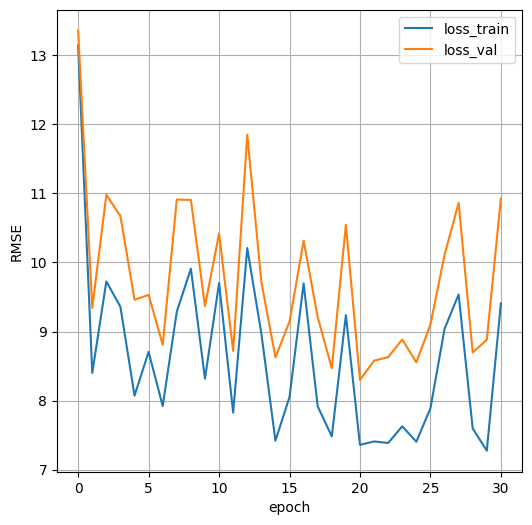

In [46]:
fig = plt.figure(figsize= (6,6))
plt.plot(loss_train, label= "loss_train")
plt.plot(loss_val, label= "loss_val")

plt.grid()
plt.legend()

plt.xlabel("epoch")
plt.ylabel("RMSE")

In [ ]:
# TODO: Produce one validation RMSE heatmap per update method.
# Rows: number of hidden layers.
# Columns: neurons per hidden layer.
# Values: validation RMSE.

raise NotImplementedError


In [ ]:
# TODO: Select the final NumPy regression model using validation RMSE only.
# Then evaluate that selected model on the test set with RMSE.

# Expected variable names for the TensorFlow baseline cell:
# best_hidden_layers = ...
# best_neurons = ...
# best_regression_test_rmse = ...
# best_regression_validation_rmse = ...

raise NotImplementedError


## Scratch Linear Regression Baseline

Use your own linear regression implementation from previous labs or courseworks. Train it on the same training set and evaluate it on the same test set.


In [ ]:
class ScratchLinearRegression:
    def fit(self, X, y, epochs=5000, learning_rate=0.01):
        # TODO: paste/adapt your previous linear regression implementation.
        raise NotImplementedError

    def predict(self, X):
        # TODO: return predictions.
        raise NotImplementedError

# TODO: train and evaluate your scratch linear regression baseline.

raise NotImplementedError


## TensorFlow Regression Baseline

This baseline is provided. Run it after you have created `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `best_hidden_layers`, and `best_neurons`.


In [ ]:
import tensorflow as tf

tf.random.set_seed(0)

if "best_hidden_layers" not in globals() or "best_neurons" not in globals():
    raise NameError("Define best_hidden_layers and best_neurons from your validation search before running this cell.")

regression_patience = globals().get("regression_patience", 10)
regression_epochs = globals().get("regression_epochs", 50)
regression_learning_rate = globals().get("regression_learning_rate", 0.01)

tf_regression_model = tf.keras.Sequential()
tf_regression_model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
for _ in range(int(best_hidden_layers)):
    tf_regression_model.add(tf.keras.layers.Dense(int(best_neurons), activation="sigmoid"))
tf_regression_model.add(tf.keras.layers.Dense(1, activation="linear"))

tf_regression_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=regression_learning_rate),
    loss="mse",
)

tf_regression_history = tf_regression_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=regression_epochs,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=regression_patience,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

tf_regression_val_predictions = tf_regression_model.predict(X_val, verbose=0)
tf_regression_test_predictions = tf_regression_model.predict(X_test, verbose=0)

tf_regression_results = pd.DataFrame([
    {
        "model": "TensorFlow regression baseline",
        "hidden_layers": int(best_hidden_layers),
        "neurons_per_layer": int(best_neurons),
        "validation_rmse": float(np.sqrt(np.mean((y_val - tf_regression_val_predictions) ** 2))),
        "test_rmse": float(np.sqrt(np.mean((y_test - tf_regression_test_predictions) ** 2))),
        "epochs_trained": len(tf_regression_history.history["loss"]),
    }
])

display(tf_regression_results)


In [ ]:
# TODO: Build the final regression comparison table.
# Include at least:
# - your NumPy NN
# - your scratch linear regression
# - the TensorFlow baseline above

raise NotImplementedError


# Part 2 - Multiclass Classification With Neural Networks (50%)

## Dataset

Use `dry_bean_database.csv`. Each row is one bean described by 16 numerical features. The target column is `Class`, with 7 mutually exclusive classes.

Required preprocessing:

1. Load the dataset.
2. Remove duplicated rows.
3. Convert numeric feature columns when needed. Some copies may store decimal values as strings with comma separators.
4. Encode `Class` as a multiclass target.
5. Split into training, validation, and test sets using a 70:15:15 ratio. Use stratification.
6. Standardize features manually using only training-set statistics.


In [ ]:
dry_beans = pd.read_csv("dry_bean_database.csv", decimal=",")
display(dry_beans.head())
display(dry_beans.describe(include="all"))


In [ ]:
# TODO: Classification preprocessing.
# - Drop duplicate rows.
# - Convert all feature columns to float.
# - Encode Class as integers and one-hot vectors.

# Expected variable names:
# class_names = [...]
# X = ...
# class_labels = ...
# y = ...  # one-hot encoded target

raise NotImplementedError


In [ ]:
# TODO: Split into train/validation/test using a 70:15:15 ratio with stratification.
# TODO: Standardize X_train, X_val, and X_test using only training-set statistics.

# Expected variable names:
# X_train, X_val, X_test
# y_train, y_val, y_test
# labels_train, labels_val, labels_test

raise NotImplementedError


## NumPy Multiclass Neural Network

Implement a fully connected multiclass classifier using NumPy.

Requirements:

- The architecture must accept a list of hidden-layer sizes, for example `[64, 128, 256]`.
- Use sigmoid activation functions in hidden layers.
- Use softmax in the output layer.
- Use multiclass cross-entropy loss.
- Implement forward propagation manually.
- Implement backpropagation manually.
- Support batch GD, SGD, and mini-batch GD.
- Use early stopping.
- Track training and validation loss at each epoch.
- Use learning rate `0.01`.
- Train for at most `1000` epochs.


In [ ]:
class NeuralNetworkMulticlassClassifier:
    def __init__(self, input_size, hidden_layers, output_size):
        # TODO: initialize weights and biases for the architecture list.
        raise NotImplementedError

    def forward(self, X):
        # TODO: implement sigmoid hidden layers and softmax output.
        raise NotImplementedError

    def backward(self, activations, y_true):
        # TODO: implement backpropagation for softmax + cross-entropy.
        raise NotImplementedError

    def fit(
        self,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=1000,
        learning_rate=0.01,
        update_method="mini_batch",
        batch_size=256,
        patience=50,
    ):
        # TODO: implement training with batch, SGD, and mini-batch updates.
        # TODO: implement early stopping and restore the best weights.
        raise NotImplementedError

    def predict_proba(self, X):
        # TODO: return class probabilities.
        raise NotImplementedError

    def predict(self, X):
        # TODO: return predicted class indices.
        raise NotImplementedError


## Classification Hyperparameter Tuning

Choose 3 hidden-layer configurations. The number of neurons does not need to be the same in every layer for this part.

For each update method, train the 3 architectures and record the validation loss. This gives 9 validation results.


In [ ]:
classification_layer_configs = [
    [64],
    [128, 64],
    [128, 128, 64],
]
classification_update_methods = ["batch", "sgd", "mini_batch"]
classification_learning_rate = 0.01
classification_epochs = 1000
classification_patience = 50

# TODO: train every architecture/update-method combination.
# Store at least: update_method, architecture, validation_loss, best_epoch, stopped_epoch.

# classification_results = pd.DataFrame(...)
# display(classification_results.sort_values("validation_loss"))

raise NotImplementedError


In [ ]:
# TODO: Plot training and validation loss curves for the selected/best classifier.

raise NotImplementedError


In [ ]:
# TODO: Produce one validation-loss heatmap per update method.
# Use architecture labels on the columns.

raise NotImplementedError


In [ ]:
# TODO: Select the final NumPy classifier using validation loss only.
# Then evaluate it on the test set with AUROC, precision, F1, and accuracy.

# Expected variable name for the TensorFlow baseline cell:
# best_classification_layers = ...

raise NotImplementedError


## Scratch Logistic Regression Baseline

Use your own logistic regression implementation from previous labs or courseworks. For this multiclass dataset, you may implement one-vs-rest logistic regression or softmax regression.


In [ ]:
class ScratchLogisticRegression:
    def fit(self, X, y, epochs=1000, learning_rate=0.01):
        # TODO: paste/adapt your previous logistic regression implementation.
        raise NotImplementedError

    def predict_proba(self, X):
        # TODO: return class probabilities.
        raise NotImplementedError

    def predict(self, X):
        # TODO: return predicted class indices.
        raise NotImplementedError

# TODO: train and evaluate your scratch logistic regression baseline.

raise NotImplementedError


## TensorFlow Classification Baseline

This baseline is provided. Run it after you have created `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, `class_names`, and `best_classification_layers`.


In [ ]:
import tensorflow as tf

tf.random.set_seed(0)

if "best_classification_layers" not in globals():
    raise NameError("Define best_classification_layers from your validation search before running this cell.")

classification_patience = globals().get("classification_patience", 50)
classification_epochs = globals().get("classification_epochs", 1000)
classification_learning_rate = globals().get("classification_learning_rate", 0.01)

tf_classification_model = tf.keras.Sequential()
tf_classification_model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))
for units in best_classification_layers:
    tf_classification_model.add(tf.keras.layers.Dense(int(units), activation="sigmoid"))
tf_classification_model.add(tf.keras.layers.Dense(y_train.shape[1], activation="softmax"))

tf_classification_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=classification_learning_rate),
    loss="categorical_crossentropy",
)

tf_classification_history = tf_classification_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=classification_epochs,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=classification_patience,
            restore_best_weights=True,
        )
    ],
    verbose=0,
)

tf_classification_probabilities = tf_classification_model.predict(X_test, verbose=0)
tf_classification_predictions = np.argmax(tf_classification_probabilities, axis=1)
tf_true_labels = np.argmax(y_test, axis=1)

tf_precision, tf_recall, tf_f1, _ = precision_recall_fscore_support(
    tf_true_labels,
    tf_classification_predictions,
    average="macro",
    zero_division=0,
)

tf_classification_results = pd.DataFrame([
    {
        "model": "TensorFlow classification baseline",
        "architecture": str(list(best_classification_layers)),
        "test_macro_ovr_auroc": roc_auc_score(y_test, tf_classification_probabilities, average="macro"),
        "test_accuracy": accuracy_score(tf_true_labels, tf_classification_predictions),
        "test_macro_precision": tf_precision,
        "test_macro_recall": tf_recall,
        "test_macro_f1": tf_f1,
        "epochs_trained": len(tf_classification_history.history["loss"]),
    }
])

display(tf_classification_results)


In [ ]:
# TODO: Build the final classification comparison table and barplots.
# Include at least:
# - your NumPy NN
# - your scratch logistic regression
# - the TensorFlow baseline above

raise NotImplementedError


# Apêndice

## 1. Relembrando métodos de atualização

### Método de Stochastic Gradient Descent

The stochastic process { wt, t= 1, . . . } depends on the examples $\textbf{RANDOMLY
PICKED AT EACH ITERATION.}$



$\textit{Large-Scale Machine Learning with Stochastic Gradient Descent, Bottou (2010); Referenciado pelo Bishop em Deep Learning: Foudantions and Concepts p. 215}$


### Método de mini-batch

Another consideration in choosing the
mini-batch size is the desire to make efficient use of the hardware architecture on
which the code is running. For example, on some hardware platforms, mini-batch
sizes that are powers of 2 (for example, 64, 128, 256, ...) work well.

One important consideration when using mini-batches is that $\textbf{THE CONSTITUENT DATA
POINTS SHOULD BE CHOSEN RANDOMLY FROM THE DATA SET}$, since in raw data sets there
may be correlations between successive data points arising from the way the data
was collected (for example, if the data points have been ordered alphabetically or
by date). This is often handled by randomly shuffling the entire data set and then
subsequently drawing mini-batches as successive blocks of data. The data set can
also be reshuffled between iterations through the data set, so that each mini-batch is
unlikely to have been used before, which can help escape local minima. The variant
of stochastic gradient descent with mini-batches is summarized in Algorithm 7.2.
Note that the learning algorithm is often still called ‘stochastic gradient descent’
even when mini-batches are used.

$\textit{Deep Learning: Foudantions and Concepts p. 216}$

